In [3]:
import pandas as pd 
import numpy as numpy

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [6]:
df = pd.read_csv("demand_forecasting.csv")


In [7]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [8]:
df.dtypes


Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [9]:
df['Date']=pd.to_datetime(df['Date'])

In [10]:
df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [14]:
df.describe(include = 'object').T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [15]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [16]:
df['Year']= df['Date'].dt.year
df['Month']= df['Date'].dt.month
df['Day']=df['Date'].dt.day
df['Weekday']=df['Date'].dt.day_name()

In [17]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='object')

In [18]:
df['Discounted_Price']=df['Price']*(1-df['Discount']/100)

In [19]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday',
       'Discounted_Price'],
      dtype='object')

In [20]:
df['Sell Through Rate']=df['Units Sold']/df['Inventory Level']

In [21]:
df['Sell Through Rate'].describe().T

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [22]:
df.groupby('Category')['Demand'].agg(['mean','sum','std']).sort_values(by='sum',ascending=False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [23]:
df.groupby(['Region', 'Seasonality'])['Demand'].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [24]:
df.groupby('Promotion')['Demand'].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [25]:
pd.pivot_table(df,
    values='Demand',
    index='Month',
    columns='Category',
    aggfunc='mean'
)

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


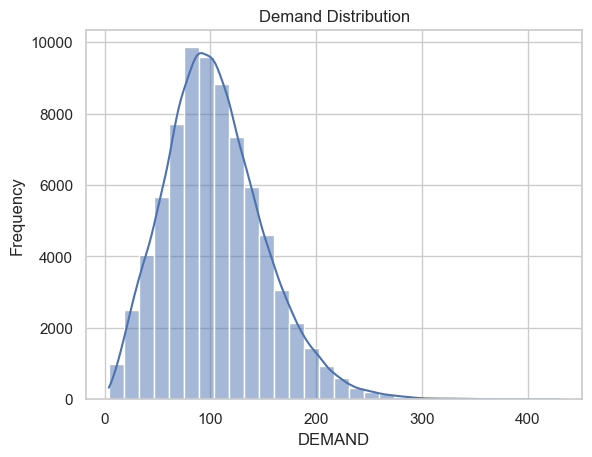

In [26]:
sns.histplot(df['Demand'], bins=30, kde=True)
plt.title('Demand Distribution')
plt.xlabel('DEMAND')
plt.ylabel('Frequency')
plt.show()

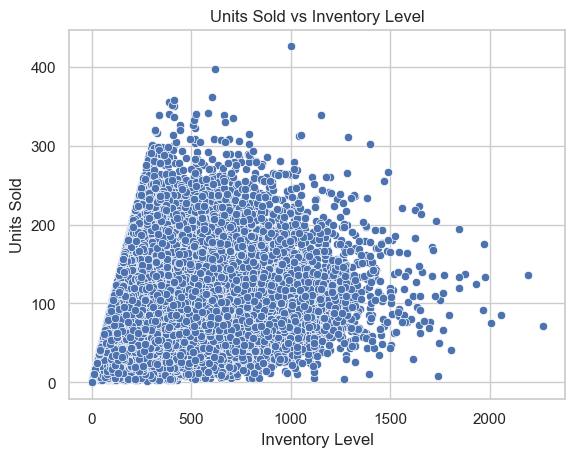

In [27]:
sns.scatterplot(df, x = 'Inventory Level', y = 'Units Sold')
plt.title('Units Sold vs Inventory Level')
plt.xlabel('Inventory Level')
plt.ylabel('Units Sold')
plt.show()


/var/folders/4n/rmxmrq1s2w9bp_fbgx4mcp8m0000gn/T/ipykernel_55153/1665784209.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df,x='Category',y='Demand', palette='Set2')


<function matplotlib.pyplot.show(close=None, block=None)>

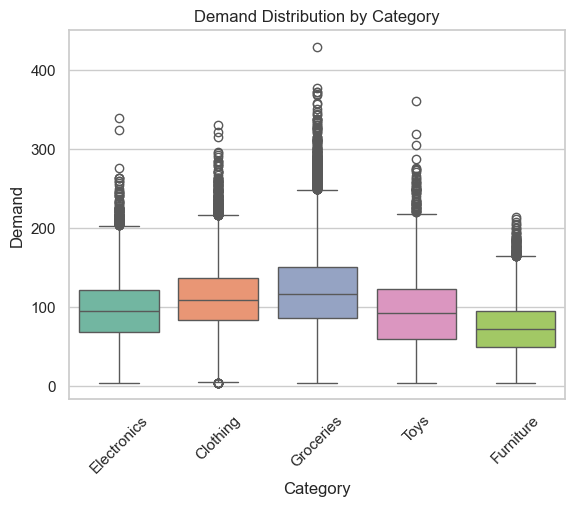

In [28]:
sns.boxplot(df,x='Category',y='Demand', palette='Set2')
plt.xticks(rotation=45)
plt.title('Demand Distribution by Category')
plt.show

/var/folders/4n/rmxmrq1s2w9bp_fbgx4mcp8m0000gn/T/ipykernel_55153/3352570375.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x = 'Weather Condition', y = 'Demand', palette = 'Set3')


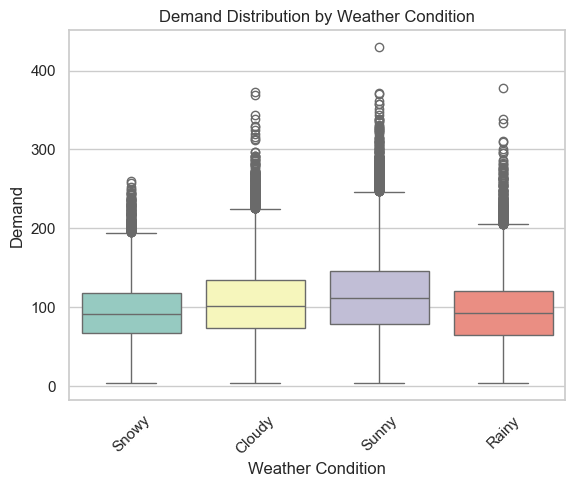

In [29]:
sns.boxplot(df, x = 'Weather Condition', y = 'Demand', palette = 'Set3')
plt.xticks(rotation=45)
plt.title('Demand Distribution by Weather Condition')
plt.show()

In [30]:
Monthly_demand = df.groupby('Month')['Demand'].mean()
 

In [31]:
Monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

Text(0.5, 1.0, 'Average Demand by Month')

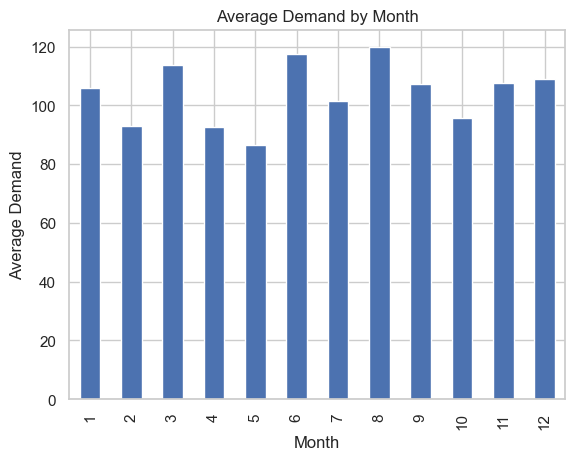

In [32]:
Monthly_demand.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Demand')
plt.title('Average Demand by Month')

In [33]:
daily_demand = df.groupby('Date')['Demand'].sum()

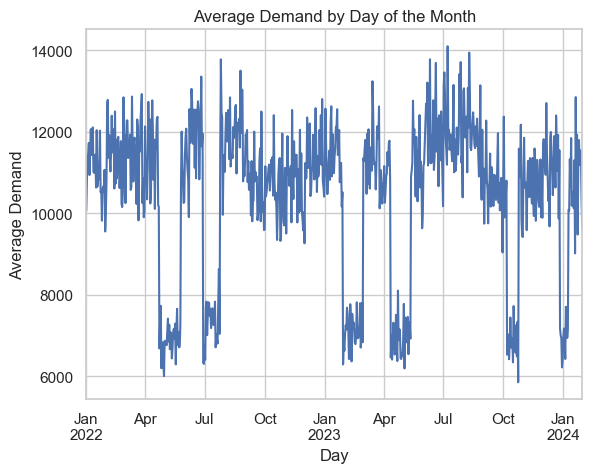

In [34]:
daily_demand.plot()
plt.xlabel('Day')
plt.ylabel('Average Demand')
plt.title('Average Demand by Day of the Month')
plt.show()

/var/folders/4n/rmxmrq1s2w9bp_fbgx4mcp8m0000gn/T/ipykernel_55153/1179371204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x = 'Promotion', y ='Demand', palette = 'Set2')


<Axes: xlabel='Promotion', ylabel='Demand'>

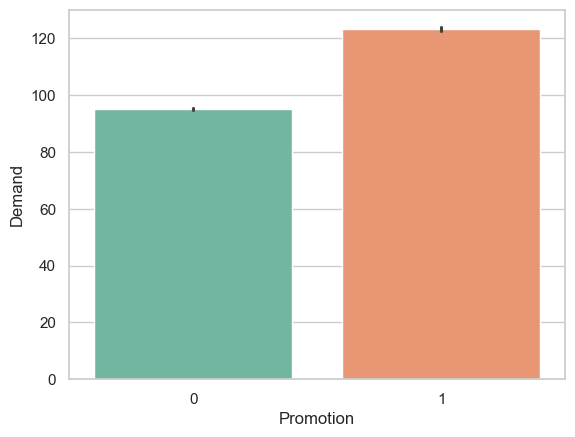

In [35]:
sns.barplot(df, x = 'Promotion', y ='Demand', palette = 'Set2')

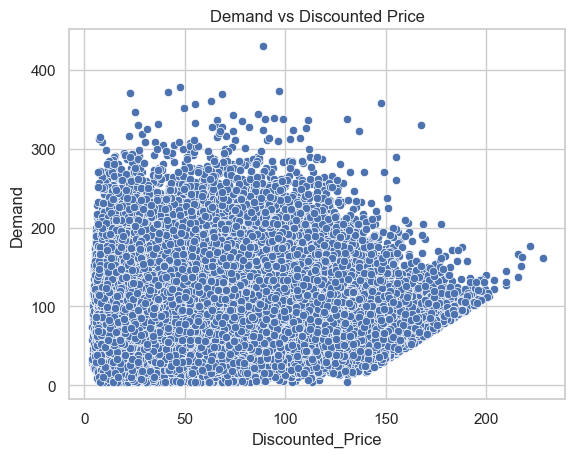

In [36]:
sns.scatterplot(df,x='Discounted_Price',y='Demand')
plt.title('Demand vs Discounted Price')
plt.show()

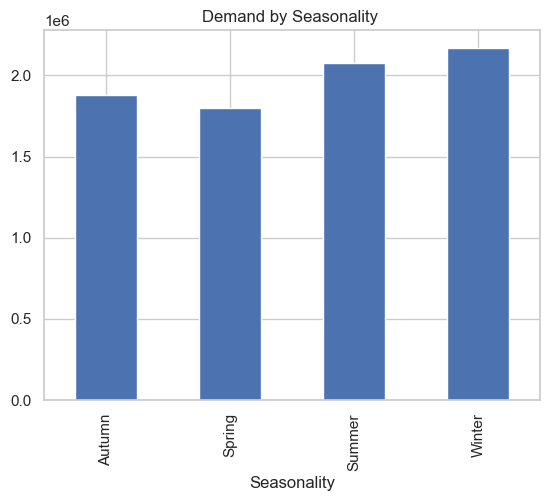

In [37]:
df.groupby('Seasonality')['Demand'].sum().plot(kind='bar', title = 'Demand by Seasonality ')
plt.show()

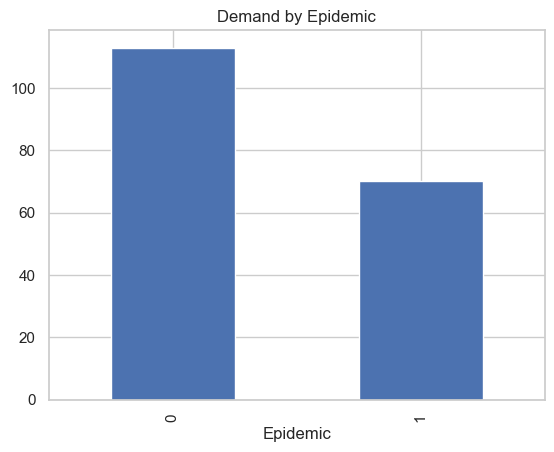

In [38]:
df.groupby('Epidemic')['Demand'].mean().plot(kind = 'bar' , title = 'Demand by Epidemic')
plt.show()

In [39]:
df.to_csv('demand_forecasting_cleaned.csv', index=False)